# Phân tích Tác động của Hình thức làm việc đến Sức khỏe Tinh thần (Mental Health & Isolation)

**Mục tiêu:** Trả lời câu hỏi cốt lõi - "Làm việc từ xa/hybrid có thực sự ảnh hưởng xấu đến tâm lý?". Chúng ta sẽ bóc tách các yếu tố: Mức độ cô lập xã hội, Tình trạng sức khỏe tinh thần (Anxiety, Burnout, ADHD...) và Sự kiệt sức do làm việc quá giờ.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
from src.data.load_data import load_raw_data
from src.features.build_features import get_da_data,get_ds_data

In [2]:
df = load_raw_data()
sns.set_theme(style = 'whitegrid')
df.head()

,Survey_Date,Age,Gender,Region,Industry,Job_Role,Work_Arrangement,Hours_Per_Week,Mental_Health_Status,Burnout_Level,Work_Life_Balance_Score,Physical_Health_Issues,Social_Isolation_Score,Salary_Range
0,2025-06-01,27,Female,Asia,Professional Services,Data Analyst,Onsite,64,Stress Disorder,High,3,Shoulder Pain; Neck Pain,2,$40K-60K
1,2025-06-01,37,Female,Asia,Professional Services,Data Analyst,Onsite,37,Stress Disorder,High,4,Back Pain,2,$80K-100K
2,2025-06-01,32,Female,Africa,Education,Business Analyst,Onsite,36,ADHD,High,3,Shoulder Pain; Eye Strain,2,$80K-100K
3,2025-06-01,40,Female,Europe,Education,Data Analyst,Onsite,63,ADHD,Medium,1,Shoulder Pain; Eye Strain,2,$60K-80K
4,2025-06-01,30,Male,South America,Manufacturing,DevOps Engineer,Hybrid,65,NaN,Medium,5,NaN,4,$60K-80K


## 1. Mức độ Cô lập xã hội (Social Isolation) giữa các hình thức làm việc

**Câu hỏi EDA:** Mức độ Cô lập xã hội (Social Isolation Score) của nhóm làm việc Remote có cao hơn đáng kể so với nhóm Onsite không?[cite: 102].
Có phải nhóm Remote đang đối mặt với "đại dịch cô đơn"?.

C:\Users\HPC\AppData\Local\Temp\ipykernel_3312\2601681924.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Work_Arrangement', y='Social_Isolation_Score', palette='Set2')


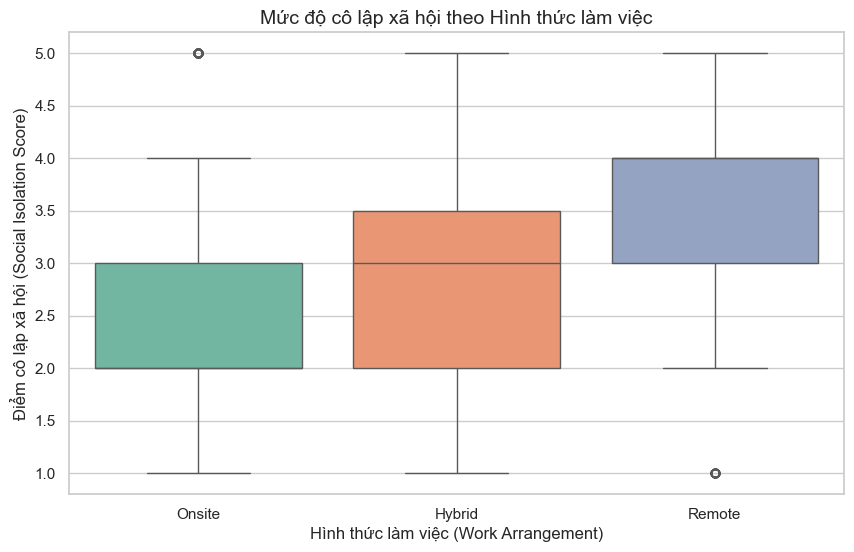

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Work_Arrangement', y='Social_Isolation_Score', palette='Set2')
plt.title('Mức độ cô lập xã hội theo Hình thức làm việc', fontsize=14)
plt.xlabel('Hình thức làm việc (Work Arrangement)')
plt.ylabel('Điểm cô lập xã hội (Social Isolation Score)')
plt.show()

* **Nhận xét (Observation):** [Bạn nhìn biểu đồ boxplot hiển thị ra và điền: Nhóm Remote có dải điểm trung vị là bao nhiêu, so với nhóm Onsite/Hybrid như thế nào].
* **Insight (Sự thật ngầm hiểu):** [Ví dụ: Dữ liệu cho thấy những người làm việc hoàn toàn từ xa (Remote) ghi nhận mức độ cô đơn cao hơn hẳn. Việc thiếu vắng các tương tác vật lý tại văn phòng đang tạo ra những rào cản lớn về mặt kết nối xã hội].

## 2. Phân bố các vấn đề Sức khỏe tinh thần (Mental Health Status)
**Câu hỏi EDA:** Các vấn đề về sức khỏe tinh thần (như Anxiety, Burnout, ADHD...) phổ biến nhất ở hình thức làm việc nào?. 
Ngành nghề hoặc nhóm công việc nào đang gặp phải vấn đề tâm lý trầm trọng nhất?

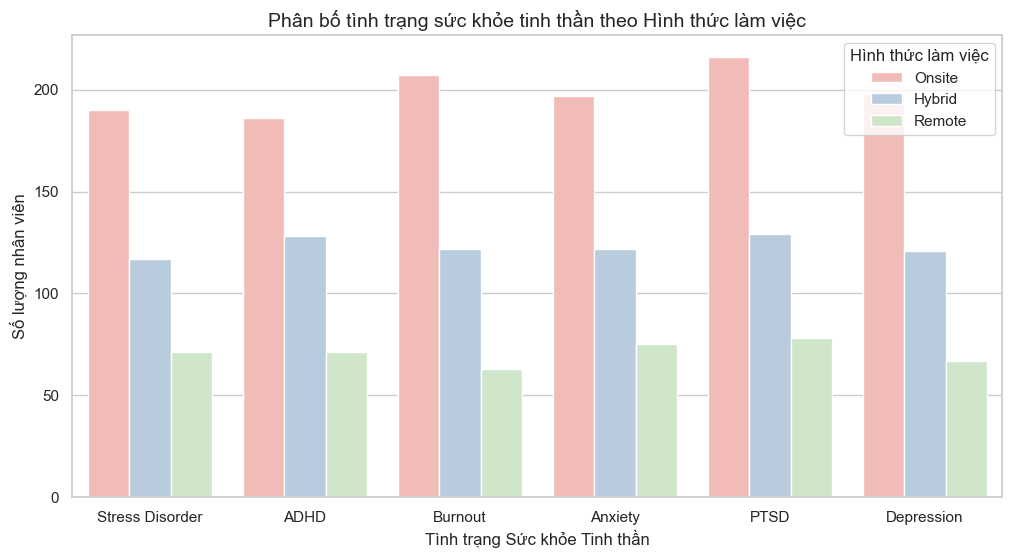

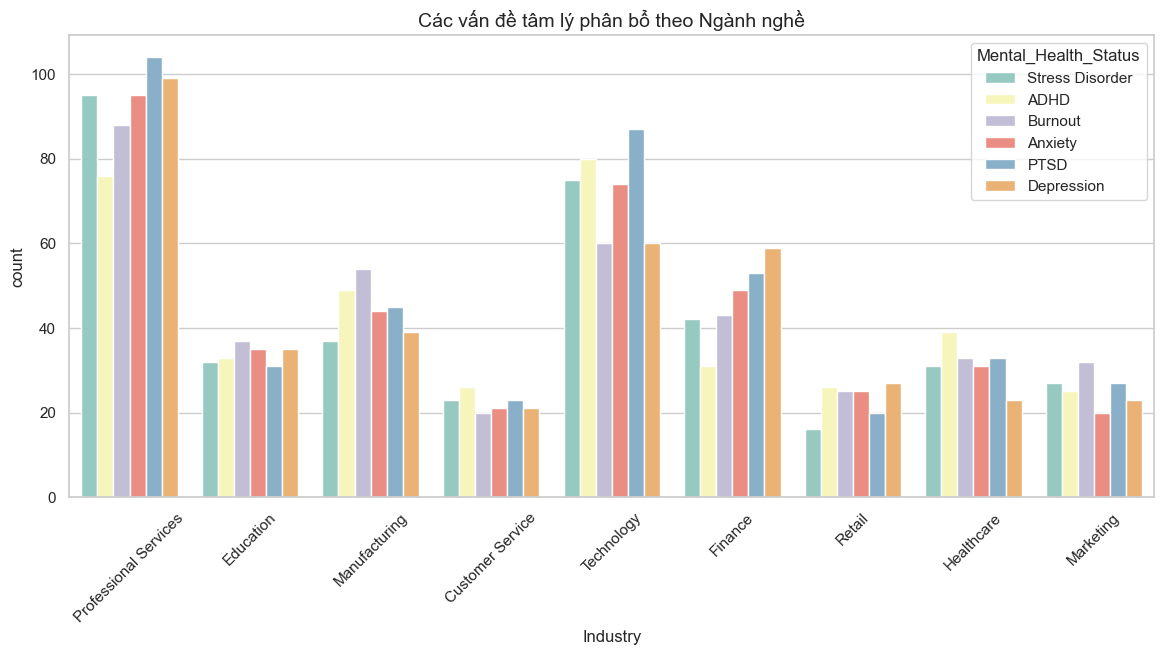

In [4]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Mental_Health_Status', hue='Work_Arrangement', palette='Pastel1')
plt.title('Phân bố tình trạng sức khỏe tinh thần theo Hình thức làm việc', fontsize=14)
plt.xlabel('Tình trạng Sức khỏe Tinh thần')
plt.ylabel('Số lượng nhân viên')
plt.legend(title='Hình thức làm việc')
plt.show()

# Phân tích thêm theo ngành nghề
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='Industry', hue='Mental_Health_Status', palette='Set3')
plt.title('Các vấn đề tâm lý phân bổ theo Ngành nghề', fontsize=14)
plt.xticks(rotation=45)
plt.show()